In [1]:
%load_ext rpy2.ipython

In [2]:
%%R

library(tidyverse)
library('GENOVA')
library(GenomicRanges)
library(GenomicFeatures)
library('TxDb.Mmusculus.UCSC.mm10.ensGene')
library("ChIPseeker")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘GENOVA’

The following object is masked from ‘package:ggplot2’:

    resolution

Loading required package: stats4
Loading required package: BiocGenerics

Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union

The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min

Loading required package: S4Vectors

Attaching package: ‘S4

In [3]:
%%R

process_regulatory_elements <- function(prefix) {
  ## For appeared loops ----
  
  # Appeared loops with enhancers within left/right anchor
  ap_enh_left <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/enh/enh_up_', prefix, '_union_1_3.bed'))
  ap_enh_right <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/enh/enh_up_', prefix, '_union_4_6.bed'))
  
  ap_enh_left$annotation <- 'Enhancer'
  ap_enh_right$annotation <- 'Enhancer'
  colnames(ap_enh_left)[1:3] <- c('seqnames', 'start', 'end')
  colnames(ap_enh_right)[1:3] <- c('seqnames', 'start', 'end')
  ap_enh_left$anchor <- 'Left'
  ap_enh_right$anchor <- 'Right'
  
  ap_enh_left <- ap_enh_left[c(1:3,16,17)]
  ap_enh_right <- ap_enh_right[c(1:3,16,17)]
  
  # Appeared loops with promoters within left/right anchor
  ap_left <- read.csv(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/pro/up_', prefix, '_ann_1_3.csv'), header = T, sep='\t')
  ap_right <- read.csv(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/pro/up_', prefix, '_ann_4_6.csv'), header = T, sep='\t')
  
  ap_pro_left <- subset(ap_left, grepl("Promoter", annotation) & !is.na(SYMBOL))
  ap_pro_right <- subset(ap_right, grepl("Promoter", annotation) & !is.na(SYMBOL))
  
  ap_pro_left$anchor <- 'Left'
  ap_pro_right$anchor <- 'Right'
  
  ap_pro_left <- ap_pro_left[c(1:3,6,21)]
  ap_pro_right <- ap_pro_right[c(1:3,6,21)]
  
  app_reg_el <- rbind(ap_enh_left, ap_enh_right, ap_pro_left, ap_pro_right)
  colnames(app_reg_el)[1] <- 'chr'
  
  app_loops <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/up_', prefix, '_union.bed'))
  app_loops <- app_loops[c(1:6)]
  colnames(app_loops) <- c("chr1", "start1", "end1", "chr2", "start2", "end2")
  
  app_reg_el$annotation <- gsub(".*Promoter.*", "Promoter", app_reg_el$annotation)
  app_pro <- subset(app_reg_el, annotation == 'Promoter')
  app_enh <- subset(app_reg_el, annotation == 'Enhancer')
  
  left_join_result <- left_join(app_loops, app_pro, by = c("chr1" = "chr", "start1" = "start", "end1" = "end"), relationship = "many-to-many") %>%
    mutate(Left = ifelse(is.na(annotation), 0, annotation))
  
  right_join_result <- left_join(app_loops, app_pro, by = c("chr2" = "chr", "start2" = "start", "end2" = "end"), relationship = "many-to-many") %>%
    mutate(Right = ifelse(is.na(annotation), 0, annotation))
  
  pro <- merge(left_join_result, right_join_result, by = c("chr1", "start1", "end1", "chr2", "start2", "end2"))
  pro <- distinct(pro, chr1,start1,end1,chr2,start2,end2, .keep_all = TRUE)
  
  left_join_result <- left_join(app_loops, app_enh, by = c("chr1" = "chr", "start1" = "start", "end1" = "end"), relationship = "many-to-many") %>%
    mutate(Left = ifelse(is.na(annotation), 0, annotation))
  
  right_join_result <- left_join(app_loops, app_enh, by = c("chr2" = "chr", "start2" = "start", "end2" = "end"), relationship = "many-to-many") %>%
    mutate(Right = ifelse(is.na(annotation), 0, annotation))
  
  enh <- merge(left_join_result, right_join_result, by = c("chr1", "start1", "end1", "chr2", "start2", "end2"))
  enh <- distinct(enh, chr1,start1,end1,chr2,start2,end2, .keep_all = TRUE)
  
  enh <- enh[c(1:6,9,12)]
  pro <- pro[c(1:6,9,12)]
  
  df <- cbind(enh, pro)
  colnames(df)[15:16] <- c('Left2', 'Right2')
  
  df$Combination_Left <- paste(df$Left, df$Left2, sep = " - ")
  df$Combination_Right <- paste(df$Right, df$Right2, sep = " - ")
  
  classify_part <- function(part) {
    if (grepl("Enhancer", part) & grepl("Promoter", part)) {
      return("Enhancer-Promoter")
    }
    else if (part == "0 - 0") {
      return("None")
    }
    else if (grepl("Enhancer", part)) {
      return("Enhancer")
    }
    else if (grepl("Promoter", part)) {
      return("Promoter")
    }
    else {
      return(part)
    }
  }
  
  classify_combination <- function(left_comb, right_comb) {
    left_class <- classify_part(left_comb)
    right_class <- classify_part(right_comb)
    
    return(paste(left_class, right_class, sep = "-"))
  }
  
  df$Classification <- mapply(classify_combination, df$Combination_Left, df$Combination_Right)
  
  groups <- c("None-None", 
              "Enhancer-None", 
              "Enhancer-Enhancer", 
              "Enhancer-Promoter", 
              "Promoter-None", 
              "Promoter-Promoter")
  
  standardize_group <- function(classification) {
    parts <- unlist(strsplit(classification, "-"))
    
    sorted_parts <- sort(parts)
    
    if (sorted_parts[1] == "Enhancer" && sorted_parts[2] == "Promoter") {
      return("Enhancer-Promoter")
    }
    
    if (grepl("Enhancer-Promoter", classification)) {
      return("Enhancer-Promoter")
    }
    
    if (sorted_parts[1] == "None" && sorted_parts[2] == "Promoter") {
      return("Promoter-None")
    }
    
    return(paste(sorted_parts, collapse = "-"))
  }
  
  df$Standardized_Classification <- sapply(df$Classification, standardize_group)
  
  group_counts <- table(factor(df$Standardized_Classification, levels = groups))
  
  app_group_counts_df <- as.data.frame(group_counts)
  app_group_counts_df$type <- 'Appeared'
  
  ## For disappeared loops ----
  
  # Disappeared loops with enhancers within left/right anchor
  dis_enh_left <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/enh/enh_down_', prefix, '_union_1_3.bed'))
  dis_enh_right <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/enh/enh_down_', prefix, '_union_4_6.bed'))
  
  dis_enh_left$annotation <- 'Enhancer'
  dis_enh_right$annotation <- 'Enhancer'
  colnames(dis_enh_left)[1:3] <- c('seqnames', 'start', 'end')
  colnames(dis_enh_right)[1:3] <- c('seqnames', 'start', 'end')
  dis_enh_left$anchor <- 'Left'
  dis_enh_right$anchor <- 'Right'
  
  dis_enh_left <- dis_enh_left[c(1:3,16,17)]
  dis_enh_right <- dis_enh_right[c(1:3,16,17)]
  
  # Disappeared loops with promoters within left/right anchor
  dis_left <- read.csv(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/pro/down_', prefix, '_ann_1_3.csv'), header = T, sep='\t')
  dis_right <- read.csv(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/pro/down_', prefix, '_ann_4_6.csv'), header = T, sep='\t')
  
  dis_pro_left <- subset(dis_left, grepl("Promoter", annotation) & !is.na(SYMBOL))
  dis_pro_right <- subset(dis_right, grepl("Promoter", annotation) & !is.na(SYMBOL))
  
  dis_pro_left$anchor <- 'Left'
  dis_pro_right$anchor <- 'Right'
  
  dis_pro_left <- dis_pro_left[c(1:3,6,21)]
  dis_pro_right <- dis_pro_right[c(1:3,6,21)]
  
  dis_reg_el <- rbind(dis_enh_left, dis_enh_right, dis_pro_left, dis_pro_right)
  colnames(dis_reg_el)[1] <- 'chr'
  
  dis_loops <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/down_', prefix, '_union.bed'))
  
  colnames(dis_loops) <- c("chr1", "start1", "end1", "chr2", "start2", "end2")
  
  dis_reg_el$annotation <- gsub(".*Promoter.*", "Promoter", dis_reg_el$annotation)
  dis_pro <- subset(dis_reg_el, annotation == 'Promoter')
  dis_enh <- subset(dis_reg_el, annotation == 'Enhancer')
  
  left_join_result <- left_join(dis_loops, dis_pro, by = c("chr1" = "chr", "start1" = "start", "end1" = "end"), relationship = "many-to-many") %>%
    mutate(Left = ifelse(is.na(annotation), 0, annotation))
  
  right_join_result <- left_join(dis_loops, dis_pro, by = c("chr2" = "chr", "start2" = "start", "end2" = "end"), relationship = "many-to-many") %>%
    mutate(Right = ifelse(is.na(annotation), 0, annotation))
  
  pro <- merge(left_join_result, right_join_result, by = c("chr1", "start1", "end1", "chr2", "start2", "end2"))
  pro <- distinct(pro, chr1,start1,end1,chr2,start2,end2, .keep_all = TRUE)
  
  left_join_result <- left_join(dis_loops, dis_enh, by = c("chr1" = "chr", "start1" = "start", "end1" = "end"), relationship = "many-to-many") %>%
    mutate(Left = ifelse(is.na(annotation), 0, annotation))
  
  right_join_result <- left_join(dis_loops, dis_enh, by = c("chr2" = "chr", "start2" = "start", "end2" = "end"), relationship = "many-to-many") %>%
    mutate(Right = ifelse(is.na(annotation), 0, annotation))
  
  enh <- merge(left_join_result, right_join_result, by = c("chr1", "start1", "end1", "chr2", "start2", "end2"))
  enh <- distinct(enh, chr1,start1,end1,chr2,start2,end2, .keep_all = TRUE)
  
  enh <- enh[c(1:6,9,12)]
  pro <- pro[c(1:6,9,12)]
  
  df <- cbind(enh, pro)
  colnames(df)[15:16] <- c('Left2', 'Right2')
  
  df$Combination_Left <- paste(df$Left, df$Left2, sep = " - ")
  df$Combination_Right <- paste(df$Right, df$Right2, sep = " - ")
  
  df$Classification <- mapply(classify_combination, df$Combination_Left, df$Combination_Right)
  df$Standardized_Classification <- sapply(df$Classification, standardize_group)
  
  group_counts <- table(factor(df$Standardized_Classification, levels = groups))
  
  dis_group_counts_df <- as.data.frame(group_counts)
  dis_group_counts_df$type <- 'Disappeared'
  
  ## For mid loops ----
  
  # Mid loops with enhancers within left/right anchor
  mid_enh_left <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/enh/enh_mid_', prefix, '_union_1_3.bed'))
  mid_enh_right <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/enh/enh_mid_', prefix, '_union_4_6.bed'))
  
  mid_enh_left$annotation <- 'Enhancer'
  mid_enh_right$annotation <- 'Enhancer'
  colnames(mid_enh_left)[1:3] <- c('seqnames', 'start', 'end')
  colnames(mid_enh_right)[1:3] <- c('seqnames', 'start', 'end')
  mid_enh_left$anchor <- 'Left'
  mid_enh_right$anchor <- 'Right'
  
  mid_enh_left <- mid_enh_left[c(1:3,16,17)]
  mid_enh_right <- mid_enh_right[c(1:3,16,17)]
  
  # Mid loops with promoters within left/right anchor
  mid_left <- read.csv(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/pro/mid_', prefix, '_ann_1_3.csv'), header = T, sep='\t')
  mid_right <- read.csv(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/pro/mid_', prefix, '_ann_4_6.csv'), header = T, sep='\t')
  
  mid_pro_left <- subset(mid_left, grepl("Promoter", annotation) & !is.na(SYMBOL))
  mid_pro_right <- subset(mid_right, grepl("Promoter", annotation) & !is.na(SYMBOL))
  
  mid_pro_left$anchor <- 'Left'
  mid_pro_right$anchor <- 'Right'
  
  mid_pro_left <- mid_pro_left[c(1:3,6,21)]
  mid_pro_right <- mid_pro_right[c(1:3,6,21)]
  
  mid_reg_el <- rbind(mid_enh_left, mid_enh_right, mid_pro_left, mid_pro_right)
  colnames(mid_reg_el)[1] <- 'chr'
  
  mid_loops <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/mid_', prefix, '_union.bed'))
  
  colnames(mid_loops) <- c("chr1", "start1", "end1", "chr2", "start2", "end2")
  
  mid_reg_el$annotation <- gsub(".*Promoter.*", "Promoter", mid_reg_el$annotation)
  mid_pro <- subset(mid_reg_el, annotation == 'Promoter')
  mid_enh <- subset(mid_reg_el, annotation == 'Enhancer')
  
  left_join_result <- left_join(mid_loops, mid_pro, by = c("chr1" = "chr", "start1" = "start", "end1" = "end"), relationship = "many-to-many") %>%
    mutate(Left = ifelse(is.na(annotation), 0, annotation))
  
  right_join_result <- left_join(mid_loops, mid_pro, by = c("chr2" = "chr", "start2" = "start", "end2" = "end"), relationship = "many-to-many") %>%
    mutate(Right = ifelse(is.na(annotation), 0, annotation))
  
  pro <- merge(left_join_result, right_join_result, by = c("chr1", "start1", "end1", "chr2", "start2", "end2"))
  pro <- distinct(pro, chr1,start1,end1,chr2,start2,end2, .keep_all = TRUE)
  
  left_join_result <- left_join(mid_loops, mid_enh, by = c("chr1" = "chr", "start1" = "start", "end1" = "end"), relationship = "many-to-many") %>%
    mutate(Left = ifelse(is.na(annotation), 0, annotation))
  
  right_join_result <- left_join(mid_loops, mid_enh, by = c("chr2" = "chr", "start2" = "start", "end2" = "end"), relationship = "many-to-many") %>%
    mutate(Right = ifelse(is.na(annotation), 0, annotation))
  
  enh <- merge(left_join_result, right_join_result, by = c("chr1", "start1", "end1", "chr2", "start2", "end2"))
  enh <- distinct(enh, chr1,start1,end1,chr2,start2,end2, .keep_all = TRUE)
  
  enh <- enh[c(1:6,9,12)]
  pro <- pro[c(1:6,9,12)]
  
  df <- cbind(enh, pro)
  colnames(df)[15:16] <- c('Left2', 'Right2')
  
  df$Combination_Left <- paste(df$Left, df$Left2, sep = " - ")
  df$Combination_Right <- paste(df$Right, df$Right2, sep = " - ")
  
  df$Classification <- mapply(classify_combination, df$Combination_Left, df$Combination_Right)
  df$Standardized_Classification <- sapply(df$Classification, standardize_group)
  
  group_counts <- table(factor(df$Standardized_Classification, levels = groups))
  
  mid_group_counts_df <- as.data.frame(group_counts)
  mid_group_counts_df$type <- 'Unchanged'
  
  ## Combine all three data frames ----
  group_counts_df <- rbind(app_group_counts_df, dis_group_counts_df, mid_group_counts_df)
  
  # Reorder the type factor
  group_counts_df$type <- factor(group_counts_df$type, levels = c('Appeared', 'Disappeared', 'Unchanged'))
  
  # Create the 100% stacked bar plot
  palette_colors <- c(
    "None-None"          = "grey68",
    "Enhancer-None"      = "wheat3",
    "Enhancer-Enhancer"  = "thistle3",
    "Enhancer-Promoter"  = "steelblue3",
    "Promoter-None"      = "darkseagreen2",
    "Promoter-Promoter"  = "lightskyblue2"
  )
  
  plot <- ggplot(group_counts_df, aes(x = type, y = Freq, fill = Var1)) +
    geom_bar(stat = "identity", position = "fill", color = "black", width = 0.7) +
    scale_fill_manual(values = palette_colors, na.value = "grey") +
    labs(x = NULL, y = NULL, fill = "Loop category", title = paste(prefix)) +
    theme_classic() +
    scale_y_continuous(
      breaks = seq(0, 1, 0.25),
      labels = scales::percent_format(accuracy = 1),
      expand = expansion(mult = c(0, 0.02))
    ) +
    coord_cartesian(ylim = c(0, 1.15)) +
    theme(
      axis.text.x = element_text(size = 15, angle = 45, hjust = 1, colour = "black"),
      axis.text.y = element_text(size = 15, colour = "black"),
      legend.text = element_text(size = 11),
      legend.title = element_text(size = 15),
      plot.title = element_text(hjust = 0.5, size = 14, face = "bold"),
      panel.border = element_rect(colour = "black", fill = NA, size = 0.8),
      aspect.ratio = 2/1
    )
  
  print(plot)
  return(list(data = group_counts_df, plot = plot))
}

In addition: Warning message:
The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


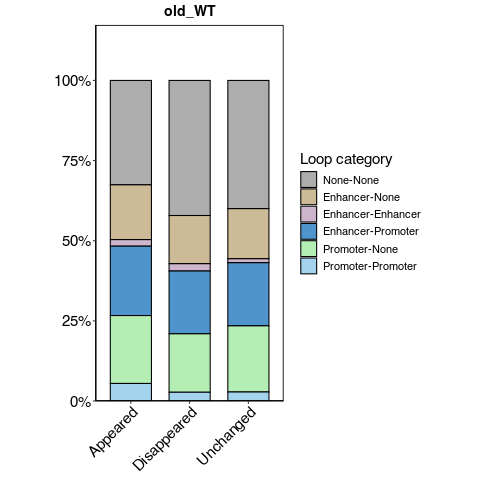

In [4]:
%%R

ko_results <- process_regulatory_elements("KO_WT")
old_results <- process_regulatory_elements("old_WT")


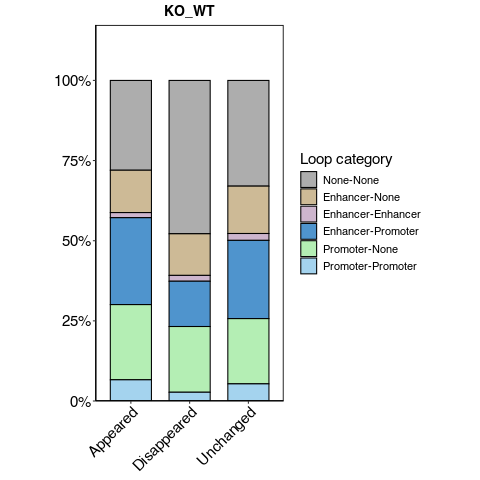

In [5]:
%%R

ko_results$plot

In [6]:
%%R

library(dplyr)
library(tidyr)

df <- ko_results$data

tab <- df %>%
  pivot_wider(names_from = type, values_from = Freq) %>%
  column_to_rownames("Var1")

tab

tab_A_vs_U <- tab[, c("Appeared", "Unchanged")]

chisq.test(tab_A_vs_U)


	Pearson's Chi-squared test

data:  tab_A_vs_U
X-squared = 4.8176, df = 5, p-value = 0.4385



In [9]:
%%R

tab_D_vs_U <- tab[, c("Disappeared", "Unchanged")]

chisq.test(tab_D_vs_U)


	Pearson's Chi-squared test

data:  tab_D_vs_U
X-squared = 29.209, df = 5, p-value = 2.109e-05



In [10]:
%%R

df <- old_results$data

tab <- df %>%
  pivot_wider(names_from = type, values_from = Freq) %>%
  column_to_rownames("Var1")

tab

tab_A_vs_U <- tab[, c("Appeared", "Unchanged")]

chisq.test(tab_A_vs_U)


	Pearson's Chi-squared test

data:  tab_A_vs_U
X-squared = 7.1559, df = 5, p-value = 0.2093



In [11]:
%%R

tab_D_vs_U <- tab[, c("Disappeared", "Unchanged")]

chisq.test(tab_D_vs_U)


	Pearson's Chi-squared test

data:  tab_D_vs_U
X-squared = 1.8684, df = 5, p-value = 0.867

